In [339]:
import pandas as pd

url_1k = "https://raw.githubusercontent.com/import-tiago/FEI/refs/heads/main/MSc/PEL309/Data/1k.csv"
url_2k = "https://raw.githubusercontent.com/import-tiago/FEI/refs/heads/main/MSc/PEL309/Data/2k.csv"
url_4k7 = "https://raw.githubusercontent.com/import-tiago/FEI/refs/heads/main/MSc/PEL309/Data/4k7.csv"

data_1k = pd.read_csv(
    url_1k,
    skiprows=17,
    header=None,
    usecols=[0, 1, 2]
)

data_1k.columns = [
    "time",
    "dac",
    "shunt"
]

data_1k = data_1k.astype(float)

data_2k = pd.read_csv(
    url_2k,
    skiprows=17,
    header=None,
    usecols=[0, 1, 2]
)

data_2k.columns = [
    "time",
    "dac",
    "shunt"
]

data_2k = data_2k.astype(float)

data_4k7 = pd.read_csv(
    url_4k7,
    skiprows=17,
    header=None,
    usecols=[0, 1, 2]
)

data_4k7.columns = [
    "time",
    "dac",
    "shunt"
]

data_4k7 = data_4k7.astype(float)

In [340]:
data_1k.head()

,time,dac,shunt
0,-1.85144,1.625156,0.002797
1,-1.85136,1.626406,0.002984
2,-1.85128,1.628437,0.002797
3,-1.85120,1.627500,0.001016
4,-1.85112,1.628906,0.003047


<Axes: xlabel='time'>

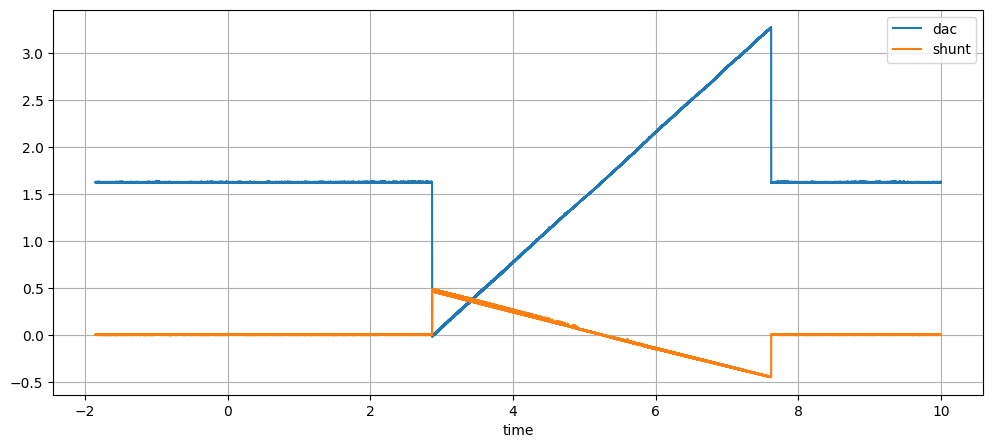

In [341]:
data_1k.plot(
    x="time",
    y=["dac", "shunt"],
    figsize=(12, 5),
    grid=True
)

<Axes: title={'center': 'Voltage [V]'}, xlabel='time'>

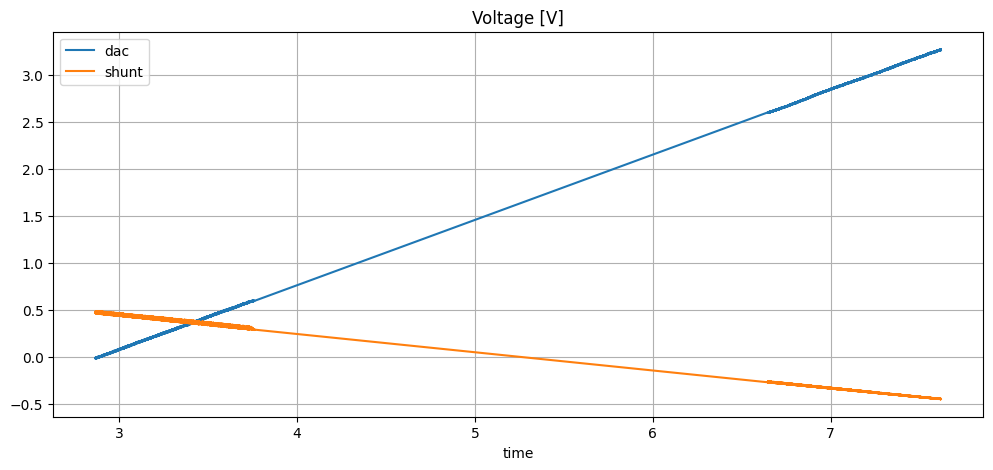

In [342]:
rest_value = 1.6
tolerance = 1

data_1k_linear = data_1k[
    (data_1k["dac"] < rest_value - tolerance) |
    (data_1k["dac"] > rest_value + tolerance)
].copy() # detecta o regime/repouse a partir de uma variação abrputa de tensão

data_1k_linear = data_1k_linear.iloc[1:-1].copy() # remove o primeiro e o último ponto, que podem ser outliers

data_1k = data_1k_linear

data_1k.plot(
    x="time",
    y=["dac", "shunt"],
    figsize=(12, 5),
    grid=True,
		title="Voltage [V]"
)

In [343]:
data_1k["current"] = ( data_1k["shunt"] / 10 ) * 1000

<Axes: title={'center': 'Current [mA]'}, xlabel='time'>

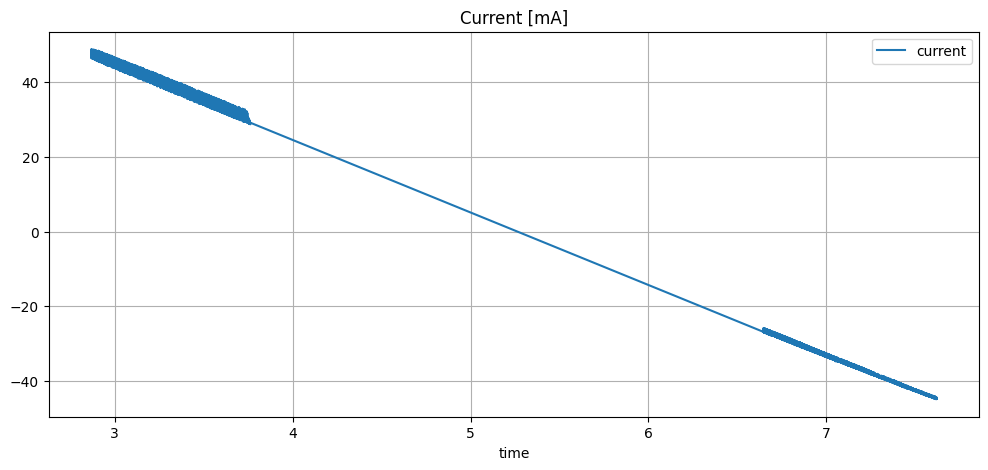

In [344]:
data_1k.plot(
    x="time",
    y=["current"],
    figsize=(12, 5),
    grid=True,
    title="Current [mA]"
)

<Axes: title={'center': 'Voltage [V]'}, xlabel='time'>

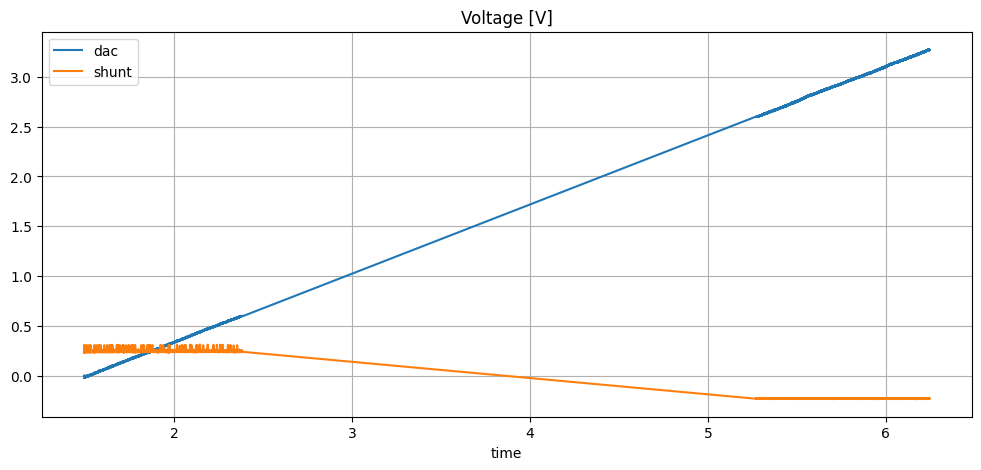

In [345]:
data_2k_linear = data_2k[
    (data_2k["dac"] < rest_value - tolerance) |
    (data_2k["dac"] > rest_value + tolerance)
].copy() # detecta o regime/repouse a partir de uma variação abrputa de tensão

data_2k_linear = data_2k_linear.iloc[1:-1].copy() # remove o primeiro e o último ponto, que podem ser outliers

data_2k = data_2k_linear

data_2k.plot(
    x="time",
    y=["dac", "shunt"],
    figsize=(12, 5),
    grid=True,
		title="Voltage [V]"
)

In [346]:
data_2k["current"] = ( data_2k["shunt"] / 10 ) * 1000

<Axes: title={'center': 'Current [mA]'}, xlabel='time'>

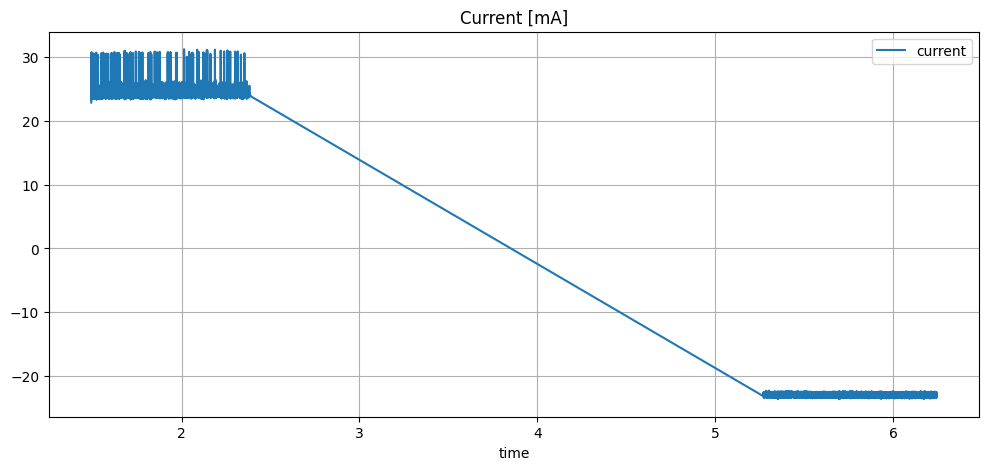

In [347]:
data_2k.plot(
    x="time",
    y=["current"],
    figsize=(12, 5),
    grid=True,
    title="Current [mA]"
)

<Axes: title={'center': 'Voltage [V]'}, xlabel='time'>

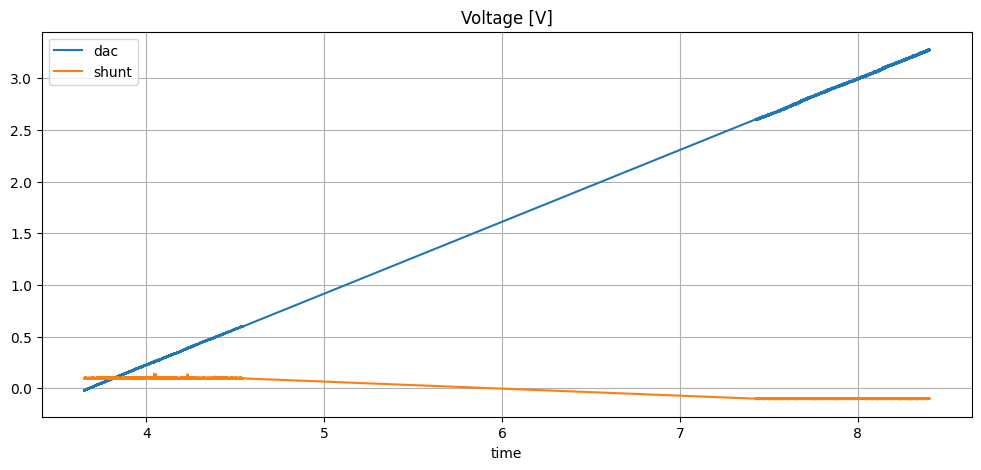

In [348]:
data_4k7_linear = data_4k7[
    (data_4k7["dac"] < rest_value - tolerance) |
    (data_4k7["dac"] > rest_value + tolerance)
].copy() # detecta o regime/repouse a partir de uma variação abrputa de tensão

data_4k7_linear = data_4k7_linear.iloc[1:-1].copy() # remove o primeiro e o último ponto, que podem ser outliers

data_4k7 = data_4k7_linear

data_4k7.plot(
    x="time",
    y=["dac", "shunt"],
    figsize=(12, 5),
    grid=True,
		title="Voltage [V]"
)

In [349]:
data_4k7["current"] = ( data_4k7["shunt"] / 10 ) * 1000

<Axes: title={'center': 'Current [mA]'}, xlabel='time'>

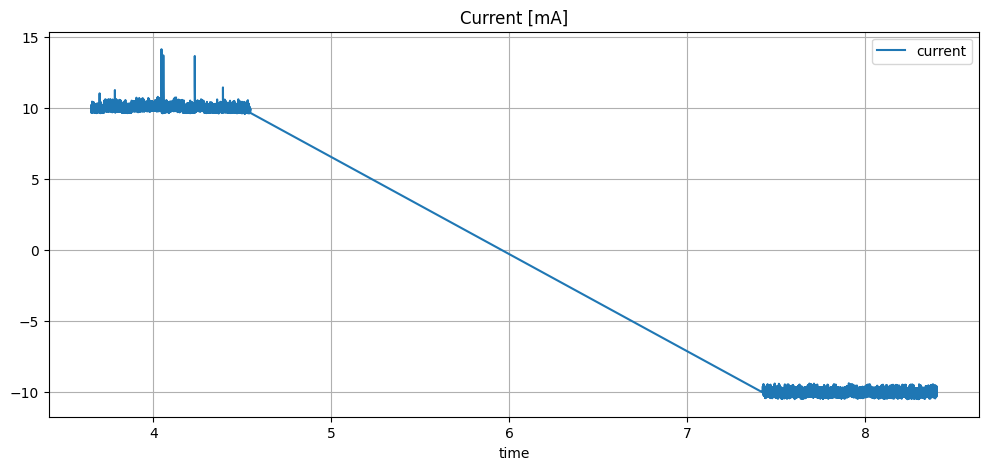

In [350]:
data_4k7.plot(
    x="time",
    y=["current"],
    figsize=(12, 5),
    grid=True,
    title="Current [mA]"
)

<Axes: title={'center': 'Current [mA]'}, xlabel='aligned_time'>

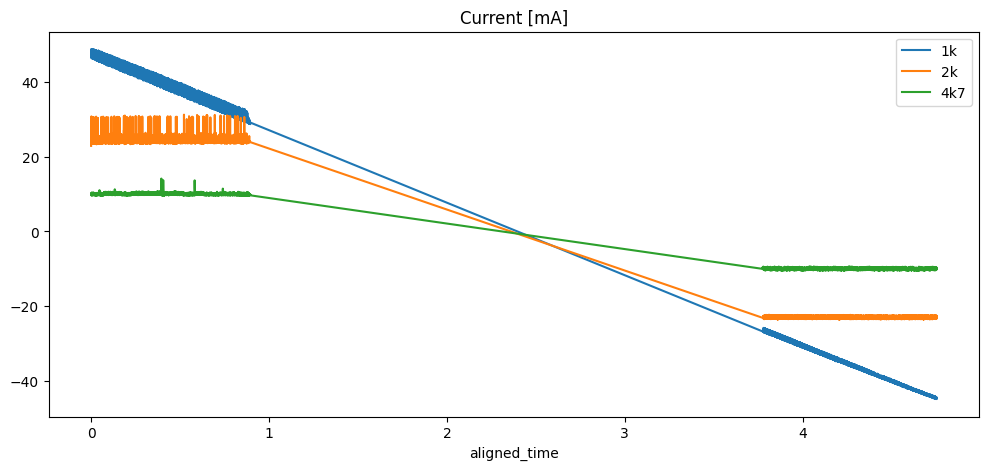

In [351]:
data_1k_aligned = data_1k.copy()
data_2k_aligned = data_2k.copy()
data_4k7_aligned = data_4k7.copy()

data_1k_aligned["aligned_time"] = data_1k_aligned["time"] - data_1k_aligned["time"].iloc[0]
data_2k_aligned["aligned_time"] = data_2k_aligned["time"] - data_2k_aligned["time"].iloc[0]
data_4k7_aligned["aligned_time"] = data_4k7_aligned["time"] - data_4k7_aligned["time"].iloc[0]

ax = data_1k_aligned.plot(
    x="aligned_time",
    y="current",
    figsize=(12, 5),
    grid=True,
    title="Current [mA]",
    label="1k"
)

data_2k_aligned.plot(
    x="aligned_time",
    y="current",
    ax=ax,
    label="2k"
)

data_4k7_aligned.plot(
    x="aligned_time",
    y="current",
    ax=ax,
    label="4k7"
)

In [352]:
dac_step = 0.05  # resolução da comparação em volts

data_1k_cmp = data_1k.copy()
data_2k_cmp = data_2k.copy()
data_4k7_cmp = data_4k7.copy()

data_1k_cmp["load"] = "1k"
data_2k_cmp["load"] = "2k"
data_4k7_cmp["load"] = "4k7"

all_data = pd.concat(
    [data_1k_cmp, data_2k_cmp, data_4k7_cmp],
    ignore_index=True
)

all_data["dac_bin"] = (all_data["dac"] / dac_step).round() * dac_step

In [353]:
comparison = all_data.pivot_table(
    index="dac_bin",
    columns="load",
    values="current",
    aggfunc="mean"
)

comparison.head()

load,1k,2k,4k7
dac_bin,,,
-0.00,46.806648,24.460979,9.921366
0.05,45.593436,24.465374,10.051694
0.10,44.213150,24.573423,10.006303
0.15,42.820679,24.543492,10.040730
0.20,41.404213,24.508461,10.092291


<Axes: title={'center': 'Output current vs DAC voltage'}, xlabel='dac_bin'>

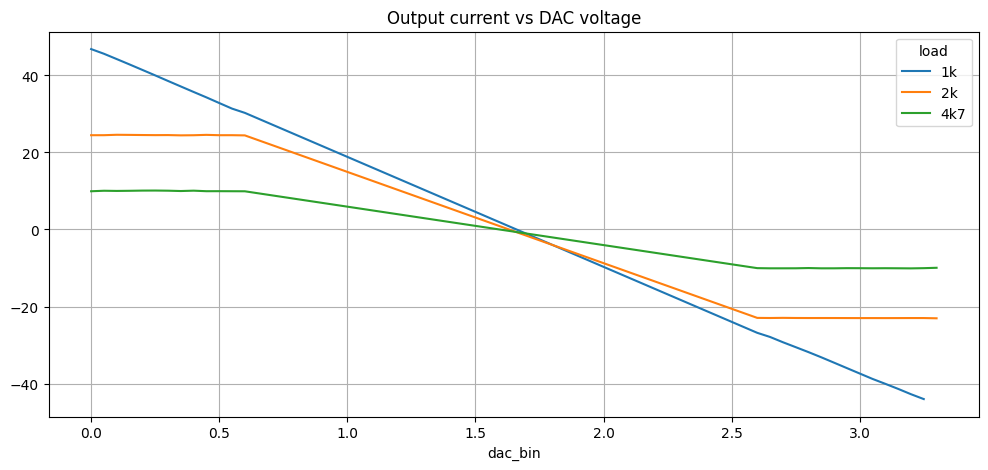

In [354]:
comparison.plot(
    figsize=(12, 5),
    grid=True,
    title="Output current vs DAC voltage"
)

In [355]:
comparison["max_current"] = comparison[["1k", "2k", "4k7"]].max(axis=1)
comparison["min_current"] = comparison[["1k", "2k", "4k7"]].min(axis=1)
comparison["current_spread"] = comparison["max_current"] - comparison["min_current"]

comparison[["1k", "2k", "4k7", "current_spread"]].head()

load,1k,2k,4k7,current_spread
dac_bin,,,,
-0.00,46.806648,24.460979,9.921366,36.885282
0.05,45.593436,24.465374,10.051694,35.541742
0.10,44.213150,24.573423,10.006303,34.206848
0.15,42.820679,24.543492,10.040730,32.779949
0.20,41.404213,24.508461,10.092291,31.311922


In [356]:
comparison["current_spread"].describe()

count    28.000000
mean     26.334976
std       6.148074
min      13.104080
25%      21.717231
50%      26.532669
75%      31.295348
max      36.885282
Name: current_spread, dtype: float64

<Axes: title={'center': 'Current spread between loads'}, xlabel='dac_bin'>

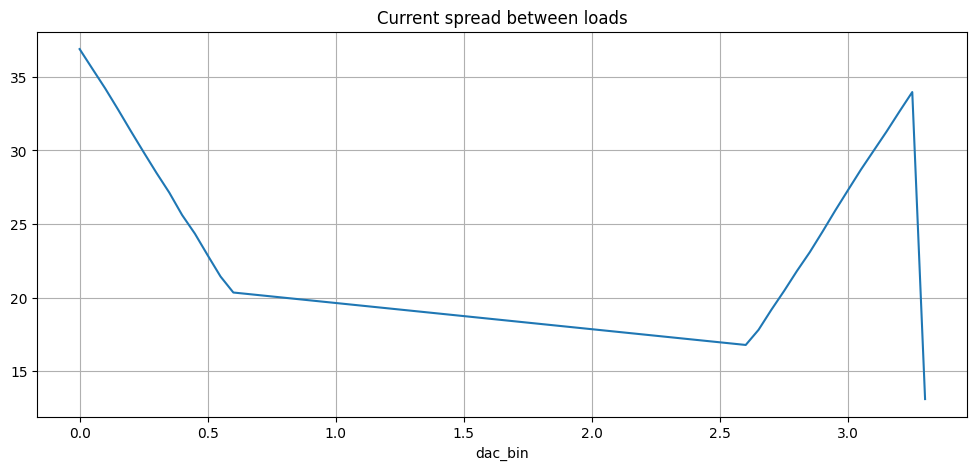

In [357]:
comparison["current_spread"].plot(
    figsize=(12, 5),
    grid=True,
    title="Current spread between loads"
)

Text(0.5, 1.0, 'Output current and load voltage vs DAC voltage')

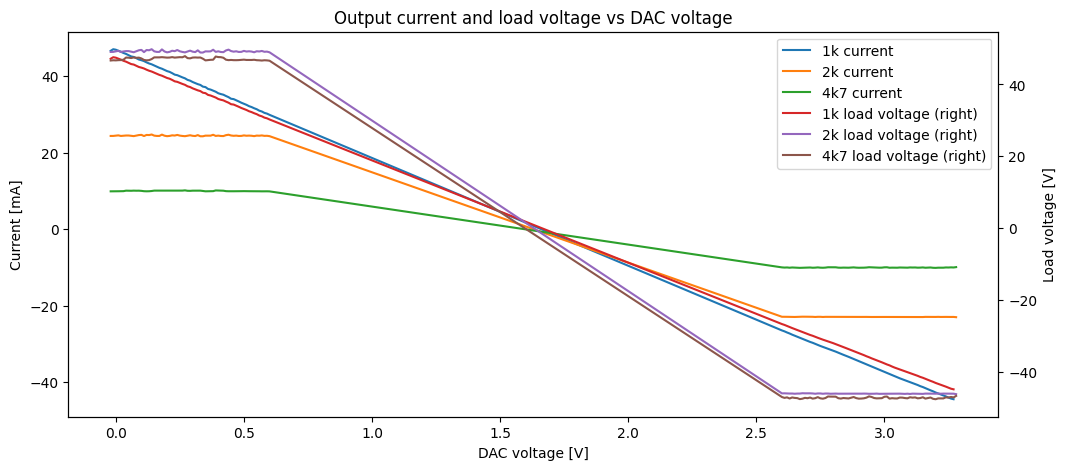

In [365]:
dac_step = 0.01

# =========================================================
# Calculate load voltage
# =========================================================

data_1k["load_voltage"] = (
    data_1k["shunt"] +
    ((data_1k["current"] / 1000) * 1000)
)

data_2k["load_voltage"] = (
    data_2k["shunt"] +
    ((data_2k["current"] / 1000) * 2000)
)

data_4k7["load_voltage"] = (
    data_4k7["shunt"] +
    ((data_4k7["current"] / 1000) * 4700)
)

# =========================================================
# Create DAC bins
# =========================================================

for df in [data_1k, data_2k, data_4k7]:

    df["dac_bin"] = (
        (df["dac"] / dac_step)
        .round() * dac_step
    )

# =========================================================
# Average values by DAC bin
# =========================================================

data_1k_avg = data_1k.groupby("dac_bin").mean(numeric_only=True)
data_2k_avg = data_2k.groupby("dac_bin").mean(numeric_only=True)
data_4k7_avg = data_4k7.groupby("dac_bin").mean(numeric_only=True)

# =========================================================
# Plot currents
# =========================================================

ax = data_1k_avg.plot(
    y="current",
    figsize=(12,5),
    grid=True,
    label="1k current"
)

data_2k_avg.plot(
    y="current",
    ax=ax,
    label="2k current"
)

data_4k7_avg.plot(
    y="current",
    ax=ax,
    label="4k7 current"
)

# =========================================================
# Plot load voltages on right axis
# =========================================================

data_1k_avg.plot(
    y="load_voltage",
    ax=ax,
    secondary_y=True,
    label="1k load voltage"
)

data_2k_avg.plot(
    y="load_voltage",
    ax=ax,
    secondary_y=True,
    label="2k load voltage"
)

data_4k7_avg.plot(
    y="load_voltage",
    ax=ax,
    secondary_y=True,
    label="4k7 load voltage"
)

# =========================================================
# Labels
# =========================================================

ax.set_xlabel("DAC voltage [V]")

ax.set_ylabel("Current [mA]")

ax.right_ax.set_ylabel("Load voltage [V]")

ax.set_title(
    "Output current and load voltage vs DAC voltage"
)